In [1]:
from pathlib import Path

from IPython.display import Image, display

from swissclim_evaluations.cli import _load_yaml, prepare_datasets, run_selected
from swissclim_evaluations.metrics.probabilistic import plot_probabilistic


In [2]:
# Locate configuration relative to the notebook location
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "example_config.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

# Load configuration via project helper to keep parity with CLI
cfg = _load_yaml(cfg_path)

# Prepare datasets using the CLI pipeline (handles selection, alignment, ensemble policy)
ds_targets, ds_predictions, ds_std, ds_predictions_std = prepare_datasets(cfg)

/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/cli.py:550: RuntimeWarning: Rechunking ground_truth to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  ds_target = data_mod.enforce_chunking(ds_target, dataset_name="ground_truth")
/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/cli.py:551: RuntimeWarning: Rechunking ml to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  ds_prediction = data_mod.enforce_chunking(ds_prediction, dataset_name="ml")


In [3]:
ds_targets

<xarray.Dataset> Size: 448MB
Dimensions:                  (init_time: 27, lead_time: 1, latitude: 720,
                              longitude: 1440, level: 3)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 24B 100 500 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 112MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
    u_component_of_wind      (level, latitude, longitude, init_time, lead_time) float32 336MB dask.array<chunksize=(1, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [4]:
ds_predictions

<xarray.Dataset> Size: 896MB
Dimensions:                  (init_time: 27, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 896MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [5]:
# Ensure the config has probabilistic enabled
cfg_modules = cfg.get("modules", {})
if not cfg_modules.get("probabilistic", False):
    print("Enabling modules.probabilistic in-memory for this run…")
    cfg_modules["probabilistic"] = True
    cfg["modules"] = cfg_modules

# Set up output directory from config relative to project root (parent of notebooks)
project_root = Path.cwd().parent
cfg_output = cfg.get("paths", {}).get("output_root", "output/notebook_prob")
out_root = (
    (project_root / cfg_output).resolve()
    if not cfg_output.startswith("/")
    else Path(cfg_output)
)
out_root.mkdir(parents=True, exist_ok=True)
print(f"Output root: {out_root}")

# Toggle to run the full pipeline via CLI orchestration
RUN_ALL = False

# If RUN_ALL is enabled, execute the orchestrator using the same config
# and skip the per-chapter call below to avoid duplication.
if RUN_ALL:
    run_selected(cfg)

# Generate standardized probabilistic plots (CRPS map + PIT histogram) only if not running all
plotting_cfg = cfg.get("plotting", {})
if not RUN_ALL:
    plot_probabilistic(ds_targets, ds_predictions, out_root, plotting_cfg)


Output root: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm
[probabilistic-plots] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_map_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png
[probabilistic-plots] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/crps_map_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.npz
[probabilistic-plots] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/pit_hist_10m_u_component_of_wind.png
[probabilistic-plots] saved /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm/probabilistic/pit_hist_10m_u_component_of_wind_ensprob.npz


CRPS Map (fallback): crps_map_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png


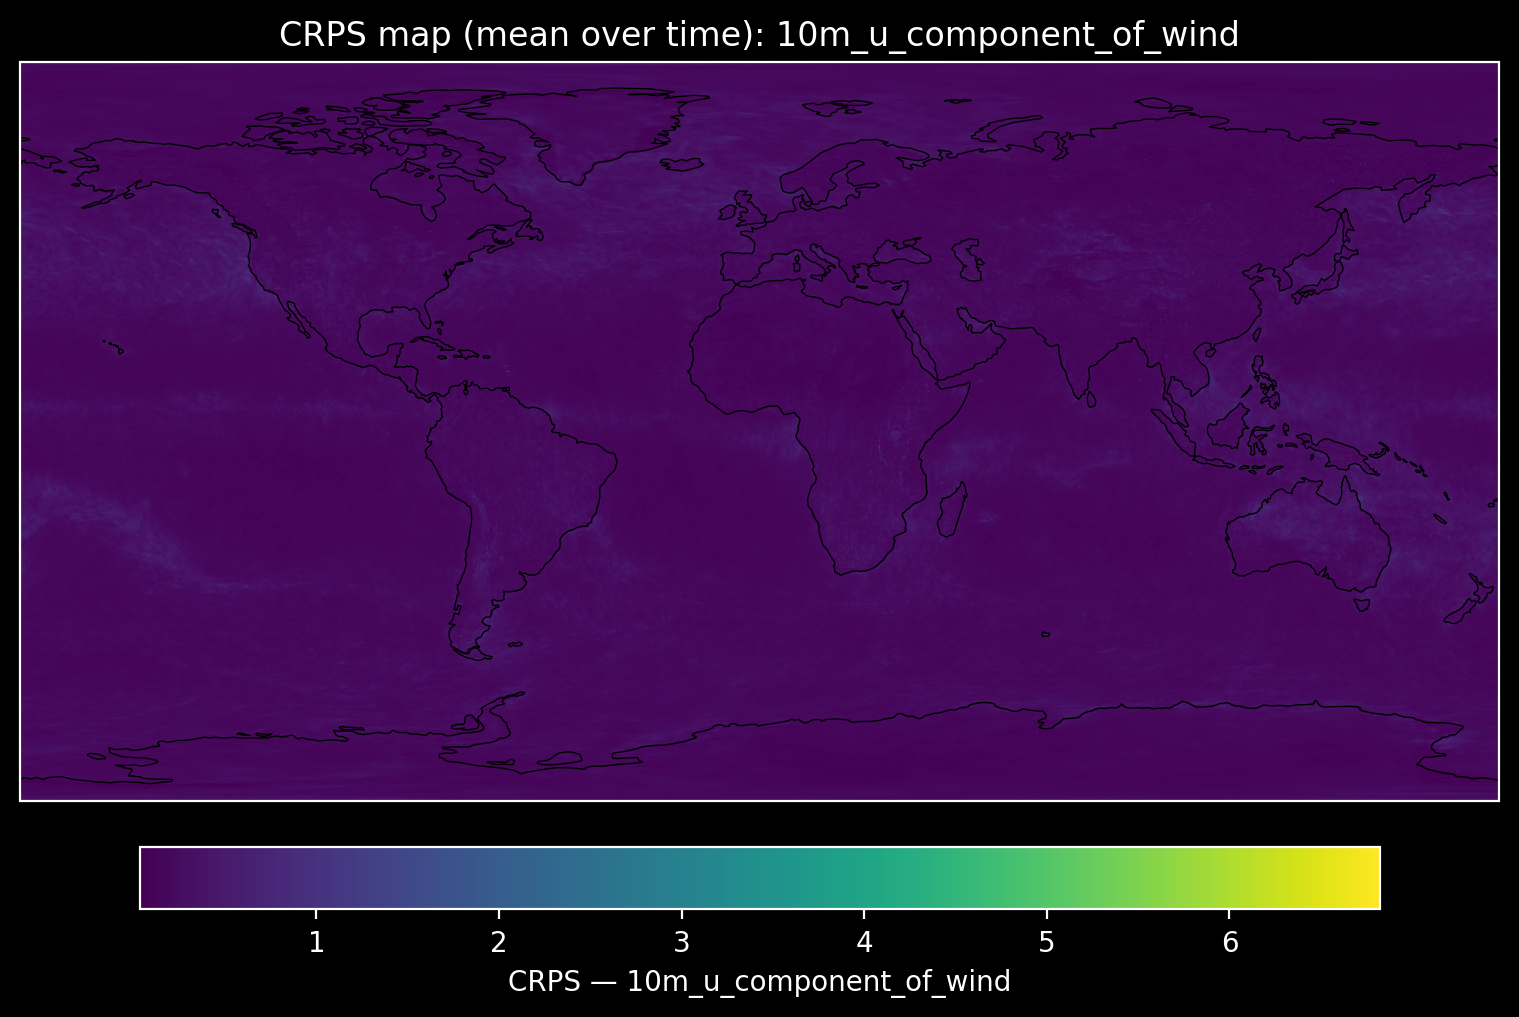

In [6]:
# Determine variable name for display from config or datasets
vars_cfg = (cfg.get("selection", {}) or {}).get("variables_2d") or list(
    ds_targets.data_vars
)
if not vars_cfg:
    raise ValueError("No variables available to display outputs.")
var = (
    vars_cfg[0]
    if vars_cfg[0] in ds_predictions.data_vars
    else [v for v in vars_cfg if v in ds_predictions.data_vars][0]
)

# Display the CRPS map PNG, robust discovery across output dirs and patterns
module_dirs = [out_root / "probabilistic", out_root / "probabilistic_wbx"]
# Prefer var-specific first, then any CRPS map
patterns = [f"crps_map_{var}.png", "crps_map_*.png"]

png_candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            png_candidates.extend(md.glob(pat))

if png_candidates:
    crps_png_path = max(png_candidates, key=lambda p: p.stat().st_mtime)
    print(f"CRPS Map ({var if f'crps_map_{var}.png' in crps_png_path.name else 'fallback'}): {crps_png_path.name}")
    display(Image(filename=str(crps_png_path)))
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
    print(f"CRPS map files not found under: {searched}")

PIT Histogram (10m_u_component_of_wind): pit_hist_10m_u_component_of_wind.png


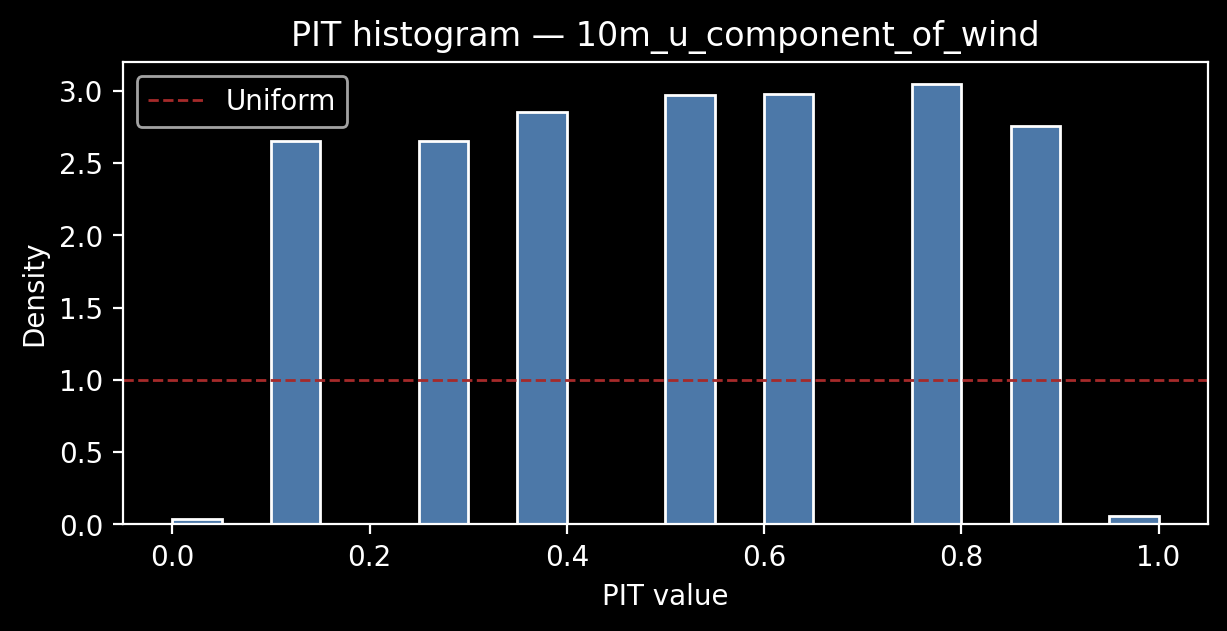

In [7]:
# Display the PIT histogram PNG, robust discovery across output dirs and patterns
module_dirs = [out_root / "probabilistic", out_root / "probabilistic_wbx"]
patterns = [f"pit_hist_{var}.png", "pit_hist_*.png"]

png_candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            png_candidates.extend(md.glob(pat))

if png_candidates:
    pit_png_path = max(png_candidates, key=lambda p: p.stat().st_mtime)
    print(f"PIT Histogram ({var if f'pit_hist_{var}.png' in pit_png_path.name else 'fallback'}): {pit_png_path.name}")
    display(Image(filename=str(pit_png_path)))
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
    print(f"PIT histogram files not found under: {searched}")